In [4]:
%reset -f

In [5]:
import sys
sys.path.append(r"C:\ThesisWork\offical_approach\mth_project\mth_project\industrial_network_analysis")
from data_preprocessing import Dataset
from data_utils import remove_outliers

import warnings
import logging

warnings_logger = logging.getLogger('warnings')
warnings_logger.setLevel(logging.WARNING)
warning_handler = logging.FileHandler('warnings.log')
warning_handler.setFormatter(logging.Formatter('%(asctime)s - %(levelname)s - %(message)s'))
warnings_logger.addHandler(warning_handler)

def warning_handler_func(message, category, filename, lineno, file=None, line=None):
    warnings_logger.warning(f"{category.__name__}: {message} (File: {filename}, Line: {lineno})")

warnings.showwarning = warning_handler_func

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import timesfm
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

import time

In [ ]:
### READ DATA
device_name = "A1-RBX-243"
df = Dataset(f'C:\\ThesisWork\\offical_approach\\mth_project\\mth_project\\industrial_network_analysis\\Data082025\\{device_name}.csv')

# names for traffic on ports - BITS SENT/RECEIVED
bits = "bits"
bits_exclude = "unused"

def get_column_names_exclude(df, search_keyword, exclude_keyword):
    df_column_names = df.get_column_names(search_keyword)
    df_column_names_excluded = []

    for col in df_column_names:
        if exclude_keyword.lower() not in col.lower():
            df_column_names_excluded.append(col)

    return df_column_names_excluded


df_columns_bits_names = get_column_names_exclude(df, bits, bits_exclude)

df_bits = df.get_column_values(df_columns_bits_names)
df_bits.columns = df_bits.columns.str.replace('Interface Gi', '')
df_bits.columns = df_bits.columns.str.replace('Valmet SUPV switch connection', '')
df_bits.columns = df_bits.columns.str.replace('Supervisory access', '')
df_bits.columns = df_bits.columns.str.replace('Bits sent', 'out')
df_bits.columns = df_bits.columns.str.replace('Bits received', 'in')
df_bits.columns = df_bits.columns.str.replace('Valmet DNA', '')

df_bits = remove_outliers(df_bits, 3).dropna()
df_bits = df_bits[:24*60]

df_bits_train, df_bits_test = np.split(df_bits, [int(0.8 * len(df_bits))])

In [ ]:
# timesFM forecasting program

### 1. Data Preparation

# Initialize scaler
scaler = RobustScaler()

# Fit scaler only on training data
train_data_normalized = pd.DataFrame(
    scaler.fit_transform(df_bits_train),
    columns=df_bits_train.columns,
    index=df_bits_train.index
)

# Apply same transformation to test data
test_data_normalized = pd.DataFrame(
    scaler.transform(df_bits_test),
    columns=df_bits_test.columns,
    index=df_bits_test.index
)

### 2. Create Model

# Set context and prediction lengths
context_length = min(512, len(train_data_normalized))  # Use available data or 512
prediction_length = len(df_bits_test)

print(f"Context length: {context_length}")
print(f"Prediction length: {prediction_length}")

# Initialize TimesFM model
tfm = timesfm.TimesFm(
    hparams=timesfm.TimesFmHparams(
        context_len=context_length,
        horizon_len=prediction_length,
        backend="cpu",
        per_core_batch_size=32,
        input_patch_len=32,      # fixed
        output_patch_len=128,    # fixed
        num_layers=50,           # fixed
        model_dims=1280,         # fixed
    ),
    checkpoint=timesfm.TimesFmCheckpoint(
        huggingface_repo_id="google/timesfm-2.0-500m-pytorch"),
)

### 3. Forecasting

# measure time required for those forecasts
start_time = time.time()

timesfm_forecasts = {}
prediction_length = len(test_data_normalized)

for i, col in enumerate(train_data_normalized.columns):
    print(f"Processing variable {i+1}/{len(train_data_normalized.columns)}: {col}")
    
    # Prepare data for TimesFM (requires specific format)
    df_input = train_data_normalized[[col]].reset_index()
    df_input.columns = ["ds", "y"]
    df_input["unique_id"] = col
    
    # Generate forecast
    try:
        forecast_df = tfm.forecast_on_df(
            inputs=df_input,
            freq="1 min",  # adjusted frequency
            value_name="y",
            num_jobs=1,
        )
        
        timesfm_forecasts[col] = forecast_df["timesfm"].values
        print(f"Forecasted {col}")
        
    except Exception as e:
        print(f"Error forecasting {col}: {str(e)}")

# create forecast DataFrame
timesfm_forecast_df = pd.DataFrame(
    timesfm_forecasts, 
    index=test_data_normalized.index
)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Time taken for forecasting: {elapsed_time:.2f} seconds")

### 4. Denormalization

# denormalize predictions to original scale
timesfm_forecast_denormalized = pd.DataFrame(
    scaler.inverse_transform(timesfm_forecast_df),
    columns=timesfm_forecast_df.columns,
    index=timesfm_forecast_df.index
)

# also denormalize the test data for comparison
test_data_denormalized = pd.DataFrame(
    scaler.inverse_transform(test_data_normalized),
    columns=test_data_normalized.columns,
    index=test_data_normalized.index
)

### 5. Evaluation

def calculate_metrics(actual, predicted, variable_name):
    """Calculate comprehensive metrics for a single variable"""
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)

    return {
        'Variable': variable_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse
    }

results = []
for col in timesfm_forecast_denormalized.columns:
    actual = test_data_denormalized[col].values
    predicted = timesfm_forecast_denormalized[col].values
    
    metrics = calculate_metrics(actual, predicted, col)
    results.append(metrics)

results_df = pd.DataFrame(results)


Context length: 512
Prediction length: 288


Fetching 5 files: 100%|██████████| 5/5 [00:00<?, ?it/s]


Processing variable 1/6: 1/1( FIREWALL connection): in
Processing dataframe with single process.
Finished preprocessing dataframe.
Finished forecasting.
Forecasted 1/1( FIREWALL connection): in
Processing variable 2/6: 1/1( FIREWALL connection): out
Processing dataframe with single process.
Finished preprocessing dataframe.
Finished forecasting.
Forecasted 1/1( FIREWALL connection): out
Processing variable 3/6: 1/3(Valmet PRP LAN_A-connection): in
Processing dataframe with single process.
Finished preprocessing dataframe.
Finished forecasting.
Forecasted 1/3(Valmet PRP LAN_A-connection): in
Processing variable 4/6: 1/3(Valmet PRP LAN_A-connection): out
Processing dataframe with single process.
Finished preprocessing dataframe.
Finished forecasting.
Forecasted 1/3(Valmet PRP LAN_A-connection): out
Processing variable 5/6: 1/4(Valmet PRP LAN_B-connection): in
Processing dataframe with single process.
Finished preprocessing dataframe.
Finished forecasting.
Forecasted 1/4(Valmet PRP LAN_B-

In [8]:
# visualization

def plot_single_variable_forecast(variable_idx, train_data_normalized, test_data_denormalized, 
                                 timesfm_forecast_denormalized, scaler, results_df):

    if variable_idx >= len(timesfm_forecast_denormalized.columns):
        print(f"Variable index {variable_idx} out of range. Max index: {len(timesfm_forecast_denormalized.columns)-1}")
        return
    
    col = timesfm_forecast_denormalized.columns[variable_idx]
    
    # Get full training data (denormalized)
    train_denormalized = pd.DataFrame(
        scaler.inverse_transform(train_data_normalized),
        columns=train_data_normalized.columns,
        index=train_data_normalized.index
    )
    
    plt.figure(figsize=(15, 8))
    
    # Plot training data
    plt.plot(train_denormalized.index, train_denormalized[col], 
             label='Training Data', color='blue', alpha=0.7)
    
    # Plot actual test data
    plt.plot(test_data_denormalized.index, test_data_denormalized[col], 
             label='Actual', color='green', linewidth=2)
    
    # Plot TimesFM forecast
    plt.plot(timesfm_forecast_denormalized.index, timesfm_forecast_denormalized[col], 
             label='TimesFM Forecast', color='red', linewidth=2, linestyle='--')
    
    # Add vertical line at forecast start
    plt.axvline(x=test_data_denormalized.index[0], color='gray', 
                linestyle=':', alpha=0.7, label='Forecast Start')
    
    plt.title(f'TimesFM Forecast vs Actual - {col}', fontsize=14)
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print metrics for this variable
    metrics = results_df[results_df['Variable'] == col].iloc[0]
    print(f"Metrics for {col}:")
    print(f"MAE: {metrics['MAE']:.4f}, RMSE: {metrics['RMSE']:.4f}")

In [15]:
# Print results

for idx, col in enumerate(results_df['Variable']):
    print(f"Metrics for {col}:")
    print(f" MAE: {results_df.loc[idx, 'MAE']:.4f},\n MSE: {results_df.loc[idx, 'MSE']:.4f},\n RMSE: {results_df.loc[idx, 'RMSE']:.4f}")

Metrics for 1/1( FIREWALL connection): in:
 MAE: 43.9447,
 MSE: 2237.4151,
 RMSE: 47.3013
Metrics for 1/1( FIREWALL connection): out:
 MAE: 714207.2485,
 MSE: 622778406646.7931,
 RMSE: 789163.1052
Metrics for 1/3(Valmet PRP LAN_A-connection): in:
 MAE: 714107.6478,
 MSE: 622594641531.1807,
 RMSE: 789046.6663
Metrics for 1/3(Valmet PRP LAN_A-connection): out:
 MAE: 82.2513,
 MSE: 17380.1389,
 RMSE: 131.8338
Metrics for 1/4(Valmet PRP LAN_B-connection): in:
 MAE: 7.9909,
 MSE: 91.8064,
 RMSE: 9.5816
Metrics for 1/4(Valmet PRP LAN_B-connection): out:
 MAE: 44.2236,
 MSE: 3398.0474,
 RMSE: 58.2928


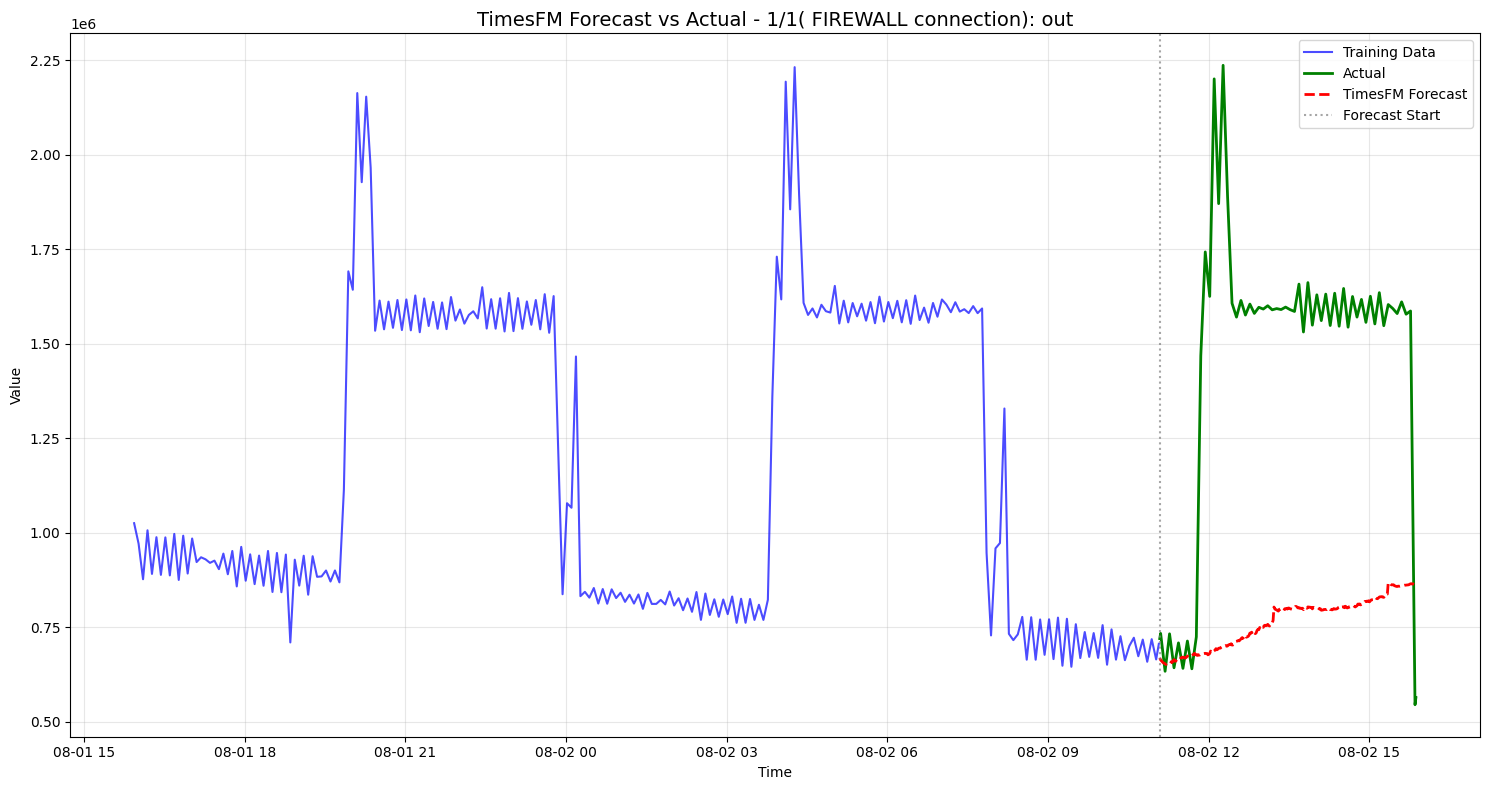

Metrics for 1/1( FIREWALL connection): out:
MAE: 714207.2485, RMSE: 789163.1052


In [19]:
results_df = pd.DataFrame(results)
plot_single_variable_forecast(
    variable_idx=1,
    train_data_normalized=train_data_normalized,
    test_data_denormalized=test_data_denormalized,
    timesfm_forecast_denormalized=timesfm_forecast_denormalized,
    scaler=scaler,
    results_df=results_df
)